<div style="border-bottom: 2px solid #e8a435; padding-bottom: 16px; margin-bottom: 24px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #e8a435; font-size: 13px; font-weight: 600; letter-spacing: 0.08em; text-transform: uppercase;">Jenner Analytics &nbsp;&bull;&nbsp; Analytique de la réussite client</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #212121; font-size: 26px; font-weight: 700; margin-top: 6px;">Analyse des causes profondes de l'attrition client</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #757575; font-size: 14px; margin-top: 4px;">Diagramme de cause à effet PROC FISHBONE pour une revue de rétention SaaS B2B mid-market</div>
</div>

## Résumé analytique

Cette analyse organise les facteurs de causes profondes de l'attrition élevée des clients SaaS en un diagramme structuré de cause à effet (Ishikawa). Le segment B2B mid-market subit une attrition d'environ 18 % par an contre une cible de 8 %. Vingt constats de causes profondes — issus des enquêtes de sortie, des entretiens de l'équipe de réussite client et de l'attribution par cohorte — sont regroupés en six catégories de causes et représentés avec `PROC FISHBONE` sous la forme d'un diagramme à 27 nœuds (un effet, six arêtes de catégorie, vingt sous-causes).

La ventilation `PROC MEANS` à l'appui montre où se concentre l'attrition attribuable. **Produit** porte le plus grand nombre de constats (5 causes, 48,1 points d'impact au total), suivi de **Tarification** (4 causes, 42,3) et **Assistance** (4 causes, 40,2). Mesurée par l'impact moyen *par cause*, **Concurrence** est la catégorie la plus sévère (moyenne 11,8), et le constat isolé au plus fort impact global est l'augmentation du prix de renouvellement de la catégorie **Tarification** sans préavis (14,2). La vue Pareto `PROC SGPLOT` classe chaque cause individuelle afin que la direction voie sur quelles arêtes agir en premier. Le livrable alimente la revue trimestrielle de rétention de l'équipe de réussite client.

## Sources de données

| Source | Description | Enregistrements |
|--------|-------------|--------|
| WORK.CHURN_RCA | Constats de causes profondes de l'attrition client consolidés à partir de l'analyse des enquêtes de sortie et de la rétrospective de l'équipe de réussite client ; chaque ligne est une cause avec sa catégorie, ses éléments probants à l'appui, et sa part estimée d'impact sur l'attrition | 20 |

---

In [1]:
/* --------------------------------------------------------
   Constats de causes profondes de l'attrition client (RCA)
   Plateforme SaaS, segment B2B mid-market.
   Chaque ligne : catégorie de cause, la cause spécifique, une
   note de sous-cause/preuve à l'appui, et la part estimée
   d'attrition qui lui est attribuable (issue de l'enquête de
   sortie et de l'attribution par cohorte).
   -------------------------------------------------------- */
data work.churn_rca;
    infile datalines dlm='|' dsd truncover;
    input category :$20. cause :$120. subcause :$160. churn_impact_pct;
    datalines;
Produit|Lacunes des fonctionnalités de base face aux concurrents entreprise|Export en masse et limites de débit API citées dans 34 % des enquêtes de départ|12.4
Produit|Capacités de reporting limitées|Aucun générateur de tableau de bord personnalisé dans l'offre standard|9.8
Produit|L'application mobile est en retard par rapport au web|3 flux de travail clés que les utilisateurs mobile uniquement ne peuvent pas terminer|8.2
Produit|Changements fréquents de l'interface sans préavis|Utilisateurs avancés perturbés par les refontes trimestrielles|7.6
Produit|Lacunes de la place de marché d'intégrations|Connecteurs natifs Salesforce et HubSpot manquants|10.1
Tarification|Augmentation du prix de renouvellement sans préavis|Augmentation de 18 % du MRR avec un préavis de 30 jours|14.2
Tarification|Le modèle par utilisateur pénalise la croissance de l'équipe|Le coût double lorsque l'équipe passe de 10 à 20 utilisateurs|11.3
Tarification|Remise initiale non renouvelable|Choc du prix lors du premier renouvellement|9.7
Tarification|Aucune incitation pour un contrat pluriannuel|Tarif annuel identique au tarif mensuel|7.1
Assistance|Le délai de première réponse dépasse 24 heures|La référence du palier est de 4 heures|10.8
Assistance|Écart de qualité du support le week-end|La couverture délocalisée manque de connaissance du produit|9.3
Assistance|Aucun CSM dédié en dessous du palier Entreprise|Les comptes mid-market n'ont pas de contact nommé|11.5
Assistance|Parcours d'escalade peu clair pour les clients|38 % des comptes perdus ont mentionné une confusion sur l'escalade|8.6
Intégration|Le délai avant valeur dépasse 90 jours|Complexité de mise en œuvre non divulguée avant-vente|12.9
Intégration|Documentation en libre-service obsolète|Dernière mise à jour il y a 11 mois|8.1
Intégration|Aucune visite guidée intégrée pour les nouvelles fonctionnalités|Adoption des fonctionnalités inférieure à 30 % à 6 mois|9.4
Concurrence|Concurrent à un prix inférieur de 30 %|Trois comptes majeurs ont cité un concurrent précis|13.1
Concurrence|Le concurrent propose une tarification à utilisateurs illimités|Élimine la pénalité par utilisateur pour les équipes en croissance|10.6
Relation client|Départ du sponsor exécutif non géré|Le champion est parti ; aucun programme de réengagement|11.7
Relation client|Fréquence des QBR réduite à annuelle|Réduction des ressources de l'équipe CS il y a 18 mois|9.2
;
run;



NOTE: DATA work.churn_rca

NOTE: Processing inline DATALINES (20 lines)

NOTE: Read 20 rows from DATALINES.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Référence : concentration de l'impact d'attrition par
   catégorie RCA. La somme montre où l'attrition attribuable
   se concentre ; le max signale la pire cause isolée dans
   chaque catégorie.
   -------------------------------------------------------- */
PROCÉDURE MOYENNES DONNÉES=work.churn_rca n sum mean MAX maxdec=1;
    CLASSE category;
    VAR churn_impact_pct;
    ÉTIQUETTE category="Catégorie" churn_impact_pct="Impact sur l'attrition (%)";
    TITRE "Analyse RCA de l'attrition client : pourcentage d'impact par catégorie";
EXÉCUTER;


                         Analyse RCA de l'attrition client : pourcentage d'impact par catégorie                         

                                                  The MEANS Procedure

                            Analysis Variable : churn_impact_pct Impact sur l'attrition (%)

        Catégorie                N Obs            Sum           Mean        Maximum
        ---------------------------------------------------------------------------
        Assistance                   4           40.2           10.1           11.5
        Concurrence                  2           23.7           11.8           13.1
        Intégration                  3           30.4           10.1           12.9
        Produit                      5           48.1            9.6           12.4
        Relation client              2           20.9           10.4           11.7
        Tarification                 4           42.3           10.6           14.2
        ----------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                         Analyse RCA de l'attrition client : pourcentage d'impact par catégorie                         




NOTE: PROC SORT data=work.churn_rca

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 20 rows from work.churn_rca.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=work.churn_rca

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


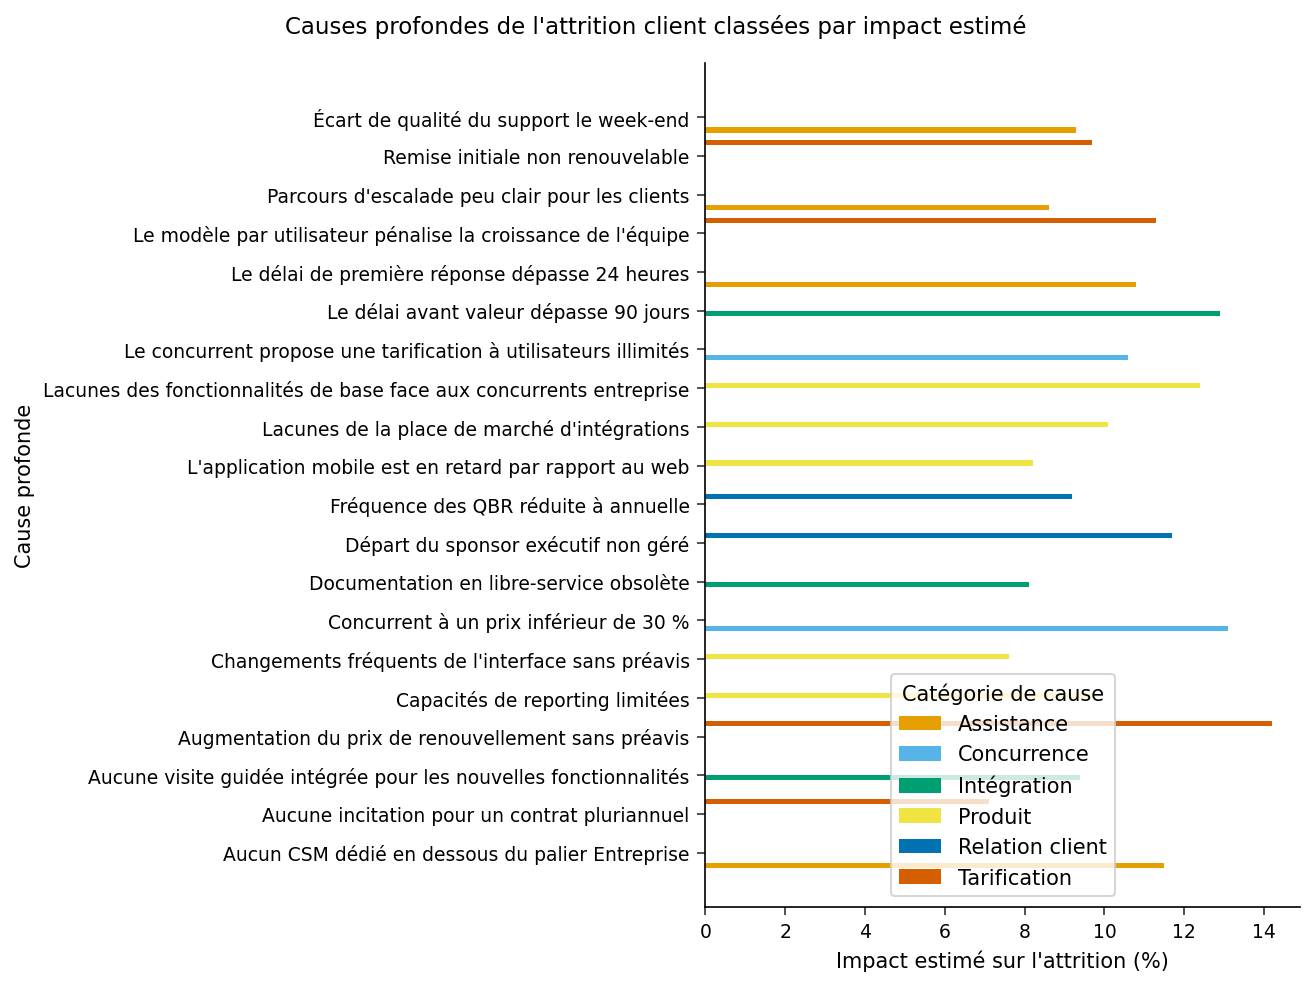

In [3]:
/* --------------------------------------------------------
   Vue Pareto : causes profondes individuelles classées par
   impact d'attrition estimé, colorées par catégorie. Ceci
   complète le diagramme en arête de poisson en quantifiant
   les arêtes les plus importantes.
   -------------------------------------------------------- */
PROCÉDURE TRIER DONNÉES=work.churn_rca;
    PAR DESCENDANT churn_impact_pct;
EXÉCUTER;

PROCÉDURE SGPLOT DONNÉES=work.churn_rca;
    HBAR cause / RESPONSE=churn_impact_pct
        group=category;
    XAXIS label="Impact estimé sur l'attrition (%)";
    YAXIS label='Cause profonde' discreteorder=data;
    keylegend / title='Catégorie de cause' position=bottom;
    TITRE "Causes profondes de l'attrition client classées par impact estimé";
EXÉCUTER;


---

### Diagramme de cause à effet (Ishikawa)

`PROC FISHBONE` construit le diagramme directement à partir de `WORK.CHURN_RCA` : chaque `category` distincte devient une arête majeure partant de l'épine centrale, et les constats individuels de `cause` pendent de leur arête de catégorie comme sous-causes. La procédure imprime ci-dessous la structure complète de cause à effet — l'effet à la tête, les six arêtes de catégorie, et chaque sous-cause regroupée sous son arête — et écrit sur le disque le graphique en arête de poisson correspondant. Le diagramme de Pareto classé ci-dessus est la vue complémentaire qui quantifie laquelle de ces arêtes porte le plus d'attrition attribuable.

In [4]:
/* --------------------------------------------------------
   PROC FISHBONE : diagramme de cause à effet de l'attrition
   client. Le diagramme est piloté directement à partir de
   WORK.CHURN_RCA, si bien que les six catégories de cause et
   leurs causes sont exactement les constats analysés ci-dessus.
   CATEGORY forme les arêtes majeures ; CAUSE pend comme
   sous-causes sous chaque arête.
   -------------------------------------------------------- */
PROCÉDURE fishbone DONNÉES=work.churn_rca;
    cause category / subcause=cause;
    effect 'Attrition client élevée (18 % annuel contre une cible de 8 %)';
    TITRE "Analyse des causes profondes de l'attrition client - segment mid-market";
    footnote "Sources : enquêtes de sortie, entretiens de l'équipe de réussite client, attribution par cohorte";
EXÉCUTER;


                         Analyse RCA de l'attrition client : pourcentage d'impact par catégorie                         


                    Analyse des causes profondes de l'attrition client - segment mid-market
                    The FISHBONE Procedure

  Cause-and-Effect Diagram

  [EFFECT] Attrition client élevée (18 % annuel contre une cible de 8 %)
    [CAUSE] Tarification (top)
      [SUB] Augmentation du prix de renouvellement sans préavis
      [SUB] Le modèle par utilisateur pénalise la croissance de l'équipe
      [SUB] Remise initiale non renouvelable
      [SUB] Aucune incitation pour un contrat pluriannuel
    [CAUSE] Concurrence (top)
      [SUB] Concurrent à un prix inférieur de 30 %
      [SUB] Le concurrent propose une tarification à utilisateurs illimités
    [CAUSE] Intégration (top)
      [SUB] Le délai avant valeur dépasse 90 jours
      [SUB] Aucune visite guidée intégrée pour les nouvelles fonctionnalités
      [SUB] Documentation en libre-service obsolète
  


NOTE: PROC FISHBONE
NOTE: PROC FISHBONE: wrote SVG to ./actual/fishbone.svg
NOTE: Output dataset has 27 nodes


---

### Interprétation

La structure de cause à effet et les chiffres `PROC MEANS` par catégorie orientent la direction vers un petit nombre de leviers à fort impact. Les deux constats isolés au plus fort impact — l'augmentation du prix de renouvellement de la catégorie **Tarification** sans préavis (14,2) et le constat de **Concurrence** selon lequel un rival vend une capacité équivalente à un prix inférieur de 30 % (13,1) — sont tous deux des enjeux commerciaux plutôt que produit, ce qui suggère que la transparence tarifaire et le positionnement concurrentiel sont les leviers les plus urgents à court terme. Le délai avant valeur de la catégorie **Intégration** dépassant 90 jours (12,9) est le plus grand constat côté service et est directement lié à la définition des attentes avant-vente.

En volume, **Produit** domine le diagramme (5 des 20 constats, 48,1 points d'impact au total), mais ses constats sont individuellement plus modestes (moyenne 9,6) que ceux de **Concurrence** (moyenne 11,8) ou de **Tarification** (moyenne 10,6) — un rappel qu'une longue liste de lacunes produit n'est pas automatiquement la priorité absolue. L'arête **Relation client** (départ du sponsor exécutif et fréquence des QBR réduite, 20,9 combinés) représente des changements de processus que l'équipe de réussite client peut mettre en œuvre dans le trimestre en cours sans investissement produit ni tarifaire, offrant la voie la plus rapide vers une amélioration mesurable de la rétention. La liste complète classée dans le diagramme de Pareto permet à la direction de séquencer les interventions par impact estimé plutôt que par taille de catégorie.

---

In [5]:
/* --------------------------------------------------------
   Exporter les constats RCA de l'attrition pour le comité de
   stratégie
   -------------------------------------------------------- */
PROCÉDURE EXPORTER DONNÉES=work.churn_rca
    OUTFILE='customer_churn_rca_findings.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;



NOTE: PROC EXPORT data=work.churn_rca outfile=customer_churn_rca_findings.csv

NOTE: Exported 20 rows to customer_churn_rca_findings.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>